In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import joblib
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score
warnings.filterwarnings('ignore')

print("📊 Model Evaluation & Business Insights")
print("======================================")


📊 Model Evaluation & Business Insights


In [6]:
model = joblib.load('../Models/churn_prediction_model.pkl')
scaler = joblib.load('../Models/scaler.pkl')
feature_columns = joblib.load('../Models/feature_columns.pkl')

df = pd.read_csv('../Data/Processed/churn_ml_dataset.csv')
X = df.drop(['Customer_ID', 'Target'], axis=1)
y = df['Target']

# Preprocess features
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Ensure same columns as training
X_encoded = X_encoded.reindex(columns=feature_columns, fill_value=0)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

X_test_scaled = scaler.transform(X_test)


In [7]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]


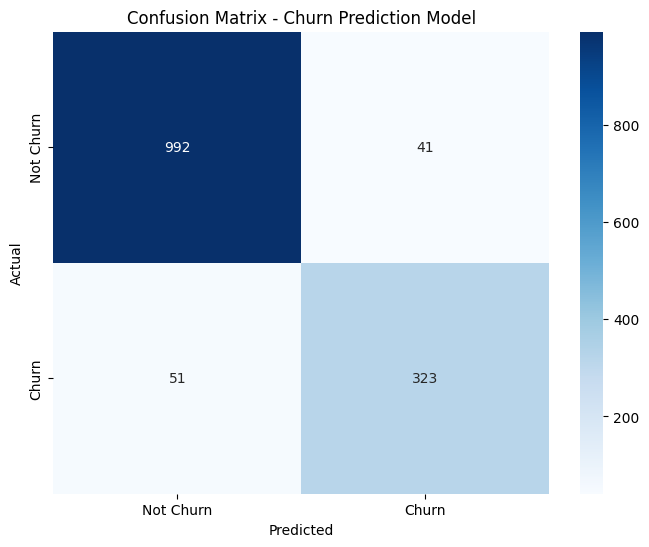

In [8]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix - Churn Prediction Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../Reports/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


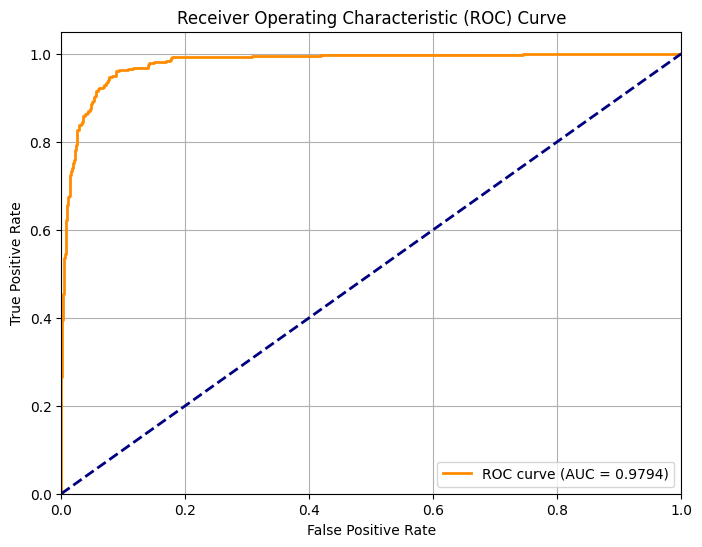

In [9]:
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('../Reports/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()


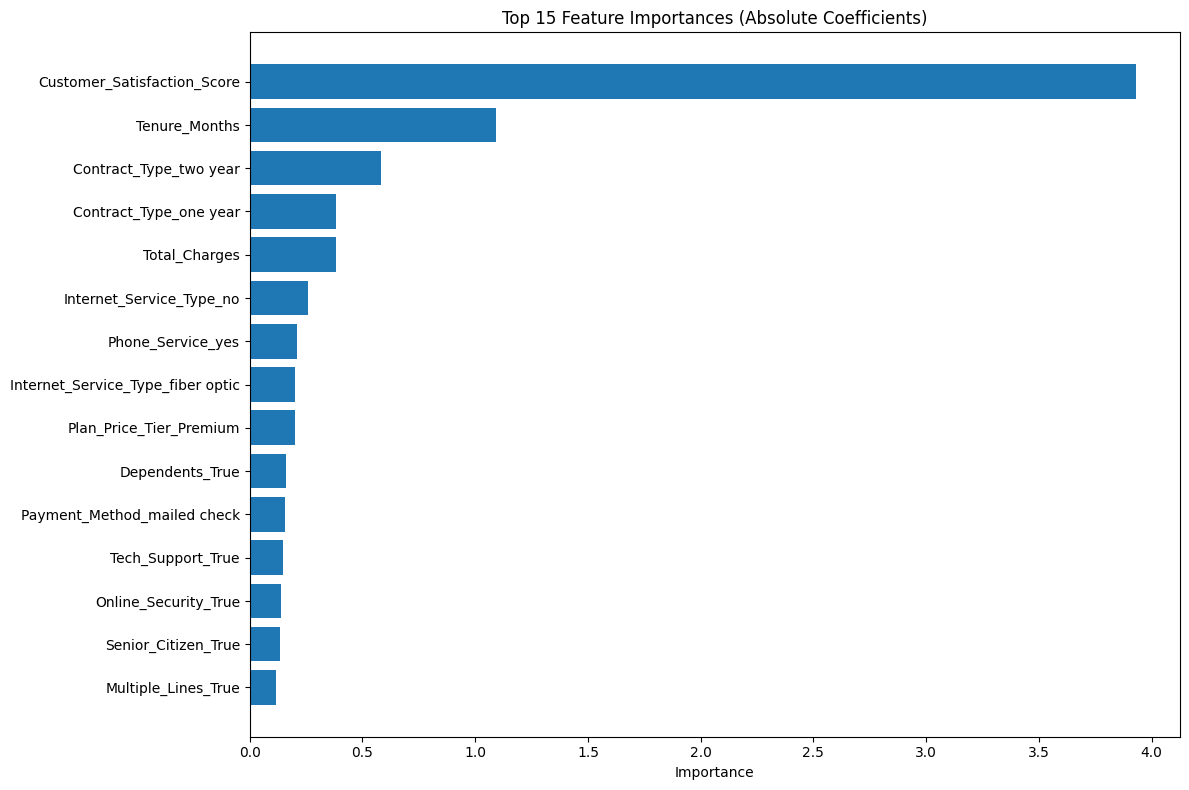

In [10]:
if hasattr(model, 'feature_importances_'):
    # Tree-based models
    importances = model.feature_importances_
elif hasattr(model, 'coef_'):
    # Logistic Regression - use absolute coefficients
    importances = np.abs(model.coef_[0])
else:
    print("⚠️ Model doesn't support feature importance")
    importances = None

if importances is not None:
    plt.figure(figsize=(12, 8))
    feature_imp = pd.DataFrame({
        'feature': feature_columns,
        'importance': importances
    }).sort_values('importance', ascending=True).tail(15)
    
    plt.barh(feature_imp['feature'], feature_imp['importance'])
    plt.title('Top 15 Feature Importances (Absolute Coefficients)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('../Reports/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()


In [13]:
print("\n💡 BUSINESS INSIGHTS:")
print("====================")
print(f"✅ Model Accuracy: {accuracy_score(y_test, y_pred):.1%}")
print(f"✅ Customers correctly identified as churners: {recall_score(y_test, y_pred):.1%}")
print(f"✅ When we predict churn, we're correct: {precision_score(y_test, y_pred):.1%} of the time")

print("\n🎯 RECOMMENDATIONS:")
print("1. Focus retention efforts on high-risk customers")
print("2. Monitor customer satisfaction scores closely")
print("3. Offer incentives for longer contract commitments")
print("4. Improve tech support and online security features")

print("\n📈 MODEL EVALUATION COMPLETED!")
print("Check ../Reports/ for all visualization files.")


💡 BUSINESS INSIGHTS:
✅ Model Accuracy: 93.5%
✅ Customers correctly identified as churners: 86.4%
✅ When we predict churn, we're correct: 88.7% of the time

🎯 RECOMMENDATIONS:
1. Focus retention efforts on high-risk customers
2. Monitor customer satisfaction scores closely
3. Offer incentives for longer contract commitments
4. Improve tech support and online security features

📈 MODEL EVALUATION COMPLETED!
Check ../Reports/ for all visualization files.
